# Lab 056 · TabArena: living benchmark literacy

**Skill:** audit a benchmark claim by reconstructing its aggregation from individual released measurements. **Implementation scope:** evaluator key parts, no new model or training. Published-result reanalysis is not training reproduction.

[Lesson](../lessons/0056-tabarena-benchmark-literacy.html) · [Reference](../reference/tabarena-benchmark-audit.html) · [Contract](l056-reproduction.md)

**Before input:** explain from memory why random versus temporal splitting changes the target question, what validation may select, and why more folds are not more datasets.

**Contract:** four frozen `tabarena-2025-06-12` method artifacts, 51 real datasets, three regimes, 816 outer splits; 9,792 rows. We analyze published measurements from real datasets (Tier A evidence), not raw data or model weights. The two-dataset weighting example is synthetic mechanism isolation only. Artifacts are committed (~254 KB), SHA256-verified, and runnable offline after setup. Python dependencies follow `requirements-labs.txt`; runtime versions print below. Bootstrap seed=56, 2,000 dataset draws. No new model/split seeds are introduced; published folds are retained. Exact paper Figure 1: **INCOMPARABLE**.

PROVIDED = read/run; TODO = implement; CHECK = immediate feedback; EXIT = evidence plus your interpretation. Five TODO functions drive the actual all-dataset audit. Budget: 35–50 minutes learning, seconds of CPU computation; no GPU required.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Concept recap

A leaderboard entry is a fitted procedure: a family plus preprocessing, validation, tuning and possibly several levels of ensembling. `default` may still include eight-fold bagging. Selecting hyperparameters and weighting ensembles must use inner validation; outer test errors evaluate the selected procedure.

Align dataset, split, method and regime before comparing. Published `metric_error` is already lower-is-better: 1−AUC, log loss or RMSE. Errors on unrelated targets cannot be averaged in their original units. Rank within one dataset/split instead, then average splits within a dataset and datasets equally.

Worked micro-example: errors `[.4,.2,.2,.9]` yield ranks `[3,1.5,1.5,4]`. If one dataset ranks A/B as 1/2 once and another ranks them 2/1 three times, pooling splits gives A=1.75/B=1.25; equal dataset weighting gives 1.5/1.5. Repeating a task changed its influence, not its evidence population.

For uncertainty, compute a paired method difference for each dataset. Resample entire datasets, preserving the paired methods and all splits. Percentiles of repeated bootstrap means describe sensitivity to that dataset mix. They do not estimate future temporal drift; crossing zero does not prove equivalence.

In [ ]:
# PROVIDED — setup, versions and location
import os,sys,json,hashlib,importlib.metadata
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
for p in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (p/'relkit').is_dir():
        ROOT=p.resolve();os.chdir(ROOT);sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run bootstrap or start in the relational workspace')
ARMS=['CatBoost','LightGBM','RealMLP','TabM']
print({p:importlib.metadata.version(p) for p in ['numpy','pandas','scipy','pyarrow']})

## 2. Freeze the question before the ranking




**Primary reading:** Erickson et al., [TabArena, version 1, §§2–3](https://arxiv.org/html/2506.16791v1). Read §2.3 and Figure 1 first; then §2.2’s dataset criteria. A *living benchmark* is maintained over time: datasets, implementations and results can change. A reproducible statement therefore identifies the snapshot, not just the website name.




The paper’s initial TabArena-v0.1 contains 51 manually curated datasets and 16 model families, targeting small-to-medium *IID* classification and regression. IID means observations are treated as independent draws from the same distribution, with random splitting appropriate for the original task. The initial scope excludes temporal or grouped dependencies, very small training sets below 500 rows, and large training sets above 250,000 rows. These are boundaries of this version, not permanent claims about every later TabArena release. [Paper §2.2](https://arxiv.org/html/2506.16791v1#S2.SS2).




That is why L055 and L056 agree: a carefully curated IID benchmark can be excellent evidence for IID prediction while leaving next-quarter prediction unanswered. An aggregate score cannot repair a mismatch in what the test population represents.






| Pin this | Our lab’s choice |
| --- | --- |
| Result snapshot | tabarena-2025-06-12 ; four checksum-verified public artifacts, retrieved 2026-09-09 |
| Method pool | CatBoost, LightGBM, RealMLP (CPU), TabM_GPU; displayed as TabM |
| Regimes | Default, tuned, tuned + ensemble; never merged into one unlabeled arm |
| Coverage | All 51 datasets, 816 outer splits per regime per method; no missing or imputed rows |
| Evaluator | Visible four-method rank/win audit; upstream primitive checked at revision e7cc6b0 |
| Evidence type | Reanalysis of released measurements. No training rerun; no claim of exact Figure 1 Elo recovery |





The frozen source hashes and download locations are in [the provenance record](_sources_l056.json). An artifact’s suite label alone cannot prove immutable contents; the lab checks SHA256, a digest of the exact file bytes, before reading results. The [official frozen-paper example](https://github.com/autogluon/tabarena/blob/e7cc6b049f9be11a6df29eb2560d9ccb2399d95c/examples/reproducibility/run_generate_main_leaderboard_neurips2025.py) is a separate route to the full method pool.

### A leaderboard is a conditional statement

A benchmark summary conditions on its dataset collection, target definitions, split generator, model roster, tuning resources, ensembling rules and metric aggregation. It is evidence about that constructed experiment. It does not become evidence about every future table simply because many model names appear in the leaderboard.

Begin with the unit of a task. Two targets derived from the same source table may share observations and feature structure. Several folds of one target are repeated evaluations of that task. Counting every result row as an independent dataset can make a large experiment appear to contain more independent information than it does.

The benchmark population also reflects inclusion decisions. Excluding extremely wide datasets, unsupported targets or tasks with failed runs changes the population on which a mean is defined. Those choices may be necessary, but their consequences belong in the interpretation. “Best on completed tasks” and “best under a policy that includes failures” can yield different decisions.

A useful audit starts with a denominator ledger: requested tasks, supported tasks, attempted fits, successful fits and rows included in each aggregate. A model with missing difficult tasks should not receive an apparently comparable mean over an easier subset without an explicit missingness policy.

For the local exercise, the archived metric errors are a finite evidence object. Recomputing them teaches aggregation and uncertainty. It does not launch the entire official search or create independent new model fits. Keep this distinction visible when describing what your notebook has reproduced.

### Curation is part of the statistical design

Appendix B.1 describes four deduplication stages: normalize names; identify different names for the same data; remove alternate versions or targets; and remove closely related tasks from one source. Why go beyond filenames? If ten variants of one hospital dataset enter a 50-task benchmark, that hospital can receive a fifth of the votes. A bootstrap cannot undo this choice: it resamples the units it is given. Equal dataset weights are useful only after deciding what deserves a distinct dataset identity.

The IID requirement refers to the original predictive task. A table of customer transactions may look like ordinary rows but require grouping by customer; a sales table may require predicting a later period. Randomly partitioning either table changes the question. TabArena's exclusion is a scope decision, not a demonstration that such tasks are unimportant. L055 studies a different deployment target. For the relational mission, carry both lessons forward: choose a strong tabular procedure using IID evidence, then evaluate it and the relational alternative under the same appropriate entity/time split.

The curation is also fallible and contestable. Appendix B.3 reports inconsistent targets and preprocessing under the same dataset name and describes why the authors read dataset provenance. Their checklist and public notes make these judgments reviewable. Manual curation is not proof that the 51 tasks randomly represent all business problems. When writing a conclusion, name the empirical population first; justify any wider inference separately.

**Diagnostic question:** all four methods lose every row of one difficult dataset before your coverage check. A pivot still looks perfectly rectangular. Can it detect the deletion? No: common coverage detects disagreement among methods; a separate expected-key manifest is needed to detect common omissions. Our hash-checked artifacts and asserted 51-dataset/816-split counts protect this frozen exercise. A newly submitted benchmark needs an external planned-task manifest, not just matching completed runs.

Source: [TabArena v1 Appendix B.1–B.3](https://arxiv.org/html/2506.16791v1#A2).

## 3. Name the fitted procedure




A model family is not the whole method. *Hyperparameters* choose the training recipe, such as width or learning rate; learned weights are fitted from training data. *HPO*, hyperparameter optimization, uses validation performance to choose among recipes. A *post-hoc ensemble* combines predictions from already trained configurations with weights selected using validation predictions.




The paper evaluates a default configuration and 200 sampled configurations for tunable families, with exceptions such as TabICL and TabDPT. It uses eight inner folds to validate configurations; most non-foundation methods also predict with an eight-fold cross-validation ensemble. Thus **“default” does not mean one unensembled fit**. Foundation-model refitting follows a different procedure. TabM’s internal shared-parameter ensemble from L054 is yet another layer: it can sit inside each fit before outer bagging or post-hoc ensembling. [Paper §2.1](https://arxiv.org/html/2506.16791v1#S2.SS1).




*Nested cross-validation* separates two jobs. The outer split reserves a test set. Inside the remaining data, each inner fit trains on seven of eight parts and predicts the eighth. Combining those held-out predictions lets the procedure select a configuration or ensemble without inspecting the outer test. For a bagged method, average the eight fitted predictors on outer-test rows, then measure error.





The paper uses repeated three-fold outer CV: ten repetitions for datasets below 2,500 samples, otherwise three. This gives 30 or 9 outer splits. The four archived artifacts have 17 datasets with 30 splits and 34 with 9: `17×30 + 34×9 = 816`. Neither 816 nor the eight inner fits is a count of independent datasets. [Paper §2.3](https://arxiv.org/html/2506.16791v1#S2.SS3).




Ask what budget is equal. Two hundred configurations equalizes candidate count, not seconds, hardware, energy, or inference latency. The paper limits a configuration evaluation to one hour on one training split and records hardware. Its AutoGluon reference pipeline has a separate four-hour recipe. A peak-performance ranking and a latency-constrained deployment ranking answer different questions. This lab inspects cached scores; it does not retune on test or remeasure timing.

### Why a family name is too coarse for attribution

“XGBoost” can mean a default configuration, the best validation-selected candidate from a search, a bagged ensemble, or a component in a larger stack. Those are different fitted procedures with different costs. The same applies to a neural architecture with preprocessing variants and multiple seeds.

Imagine procedure A trains one default model for two minutes. Procedure B searches 100 candidates, selects ten and averages them. If B wins, the result supports the complete B procedure under its resource allocation. It does not isolate the effect of one base architecture. A separate controlled experiment is needed for that attribution.

Search effort and final inference cost are different axes. A heavily tuned single model can be cheap to serve after expensive development. A lightly tuned large ensemble can be expensive on every prediction. Record training/search cost, final model size and prediction cost separately so the result can inform the intended use case.

Preprocessing belongs in this identity. Two methods may both use an MLP backbone while one uses learned feature embeddings, a different numerical transform and a stronger optimizer recipe. A benchmark taxonomy should describe those choices rather than treating the backbone name as the whole method.

When comparing archived procedures, preserve their full names. Short labels are useful in a plot, but the caption or linked manifest should map each label to the exact fitted recipe. Otherwise an attractive ranking figure becomes difficult to interpret precisely.

### Trace a prediction through the nested procedure

Let the outer training pool contain N rows and let the untouched outer test have Q rows. For one candidate configuration c, partition the N rows into eight inner validation sets. Inner fit j receives about 7N/8 rows and produces two arrays: predictions on its held-out N/8 rows, and predictions on all Q outer-test rows. For C-class classification these have shapes approximately [N/8,C] and [Q,C]. For regression there is one output per row. Scatter the held-out predictions into their original row positions to create an **out-of-fold (OOF)** array [N,C]. Each row's prediction came from a fit that excluded that row from weight fitting; its label can still be used for validation and early stopping, so OOF does not mean an untouched final test.

Compute validation error on this OOF array. The tuned procedure chooses c* using those errors, then averages the eight test-prediction arrays of c* to form [Q,C]. This is a cross-validation ensemble, also called bagging here. Its members differ in fitting rows. A post-hoc ensemble instead combines several candidate configurations: select nonnegative weights using their OOF predictions, then apply those same weights to their bagged test predictions. Averaging probabilities precedes log loss; averaging eight log losses is not the loss of the average prediction. Finally, and only after selection, compare the resulting test predictions to the Q test labels.

A concrete binary example exposes that order. Two members predict probabilities .2 and .8 for a positive test label. Their mean prediction is .5, whose log loss is −log(.5)≈.693. Their individual losses average to [−log(.2)−log(.8)]/2≈.916. The second number evaluates randomly selecting a member, not averaging its probability. Nothing guarantees a particular ensemble improves every dataset, but the object being measured must be the intended predictor.

Do not confuse the three ensemble axes. TabM-mini's k=32 members share a neural backbone within one fit; eight-fold bagging trains eight such predictors on different inner row sets; post-hoc ensembling combines configurations with different hyperparameters. Cross-family ensembling in L057 adds another axis by combining different model families. Figure 6 in TabArena uses a learned cross-family portfolio, selected with leave-one-dataset-out evaluation, size 200 and 40 ensemble selection steps (Appendix C.3). Our four-family score files cannot reconstruct those ensemble predictions: metric errors contain no information about which individual rows each model got wrong.

### The exact wrapper changes what a family name means

Appendix C.1 separates common feature handling from model-specific preprocessing. Common processing handles text/datetime columns, retains numerical values, preserves categorical identity while coding categories, drops constant/duplicate columns, and passes missingness onward. Model-specific handling then decides scaling, encoding and imputation. Applying a single numerical scaler to every family would not reproduce this design.

For our artifact names, the consequential details are: RealMLP is the CPU pipeline and handles missing numerical values using mean imputation plus an indicator; its default disables label smoothing because the benchmark uses AUC/log loss rather than accuracy. TabM_GPU uses numerical quantile preprocessing and missingness handling; Table C.8 specifies tabm-mini, k=32, piecewise-linear numerical embeddings and clipping norm 1.0. This is not the numeric small-budget L054 lab configuration. CatBoost and LightGBM rely on their integrated implementations for model-specific processing. These statements describe the paper recipes; the score files cannot independently prove which operations produced each stored error.

Foundation models are an explicit exception: after validation, they refit/use the complete outer training pool as context instead of eight-fold bagging, following author recommendations. Their applicability limits and checkpoints matter. The TabICL v1.1 checkpoint and TabDPT 1.1 used here differ from older paper versions; neither receives the 200-configuration HPO search. Do not extend an eight-inner-fit diagram to these methods without drawing the refit branch.

The one-hour limit covers a configuration's **entire eight-inner-fit evaluation** (Appendix A.2), not one hour for each of eight fits. Appendix A.3 shows why hardware affects the attainable procedure: around 16% of CPU TabM/ModernNCA runs reached that cap versus less than .1% on GPU. Equal candidate counts plus different hardware do not isolate architecture alone. Appendix A.2 also records EBM exceeding the intended time limit, a real exception to audit rather than silently erase. The AutoGluon 1.3 best-quality four-hour reference follows separate constraints.

Source: [§2.1](https://arxiv.org/html/2506.16791v1#S2.SS1), [Appendix A.2–A.3](https://arxiv.org/html/2506.16791v1#A1.SS2), and [Appendix C](https://arxiv.org/html/2506.16791v1#A3).

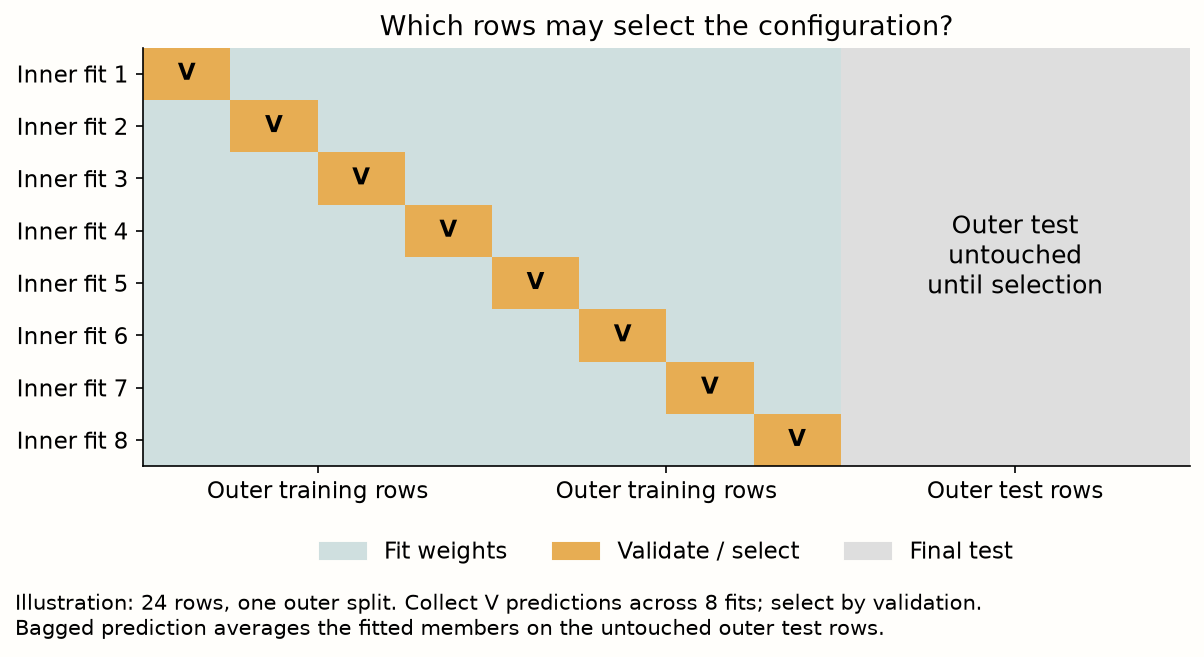

Illustrative inner/outer split boundary. Trace V rows into validation; outer-test labels remain withheld. [Open full-size figure](figures/l056/protocol.png).

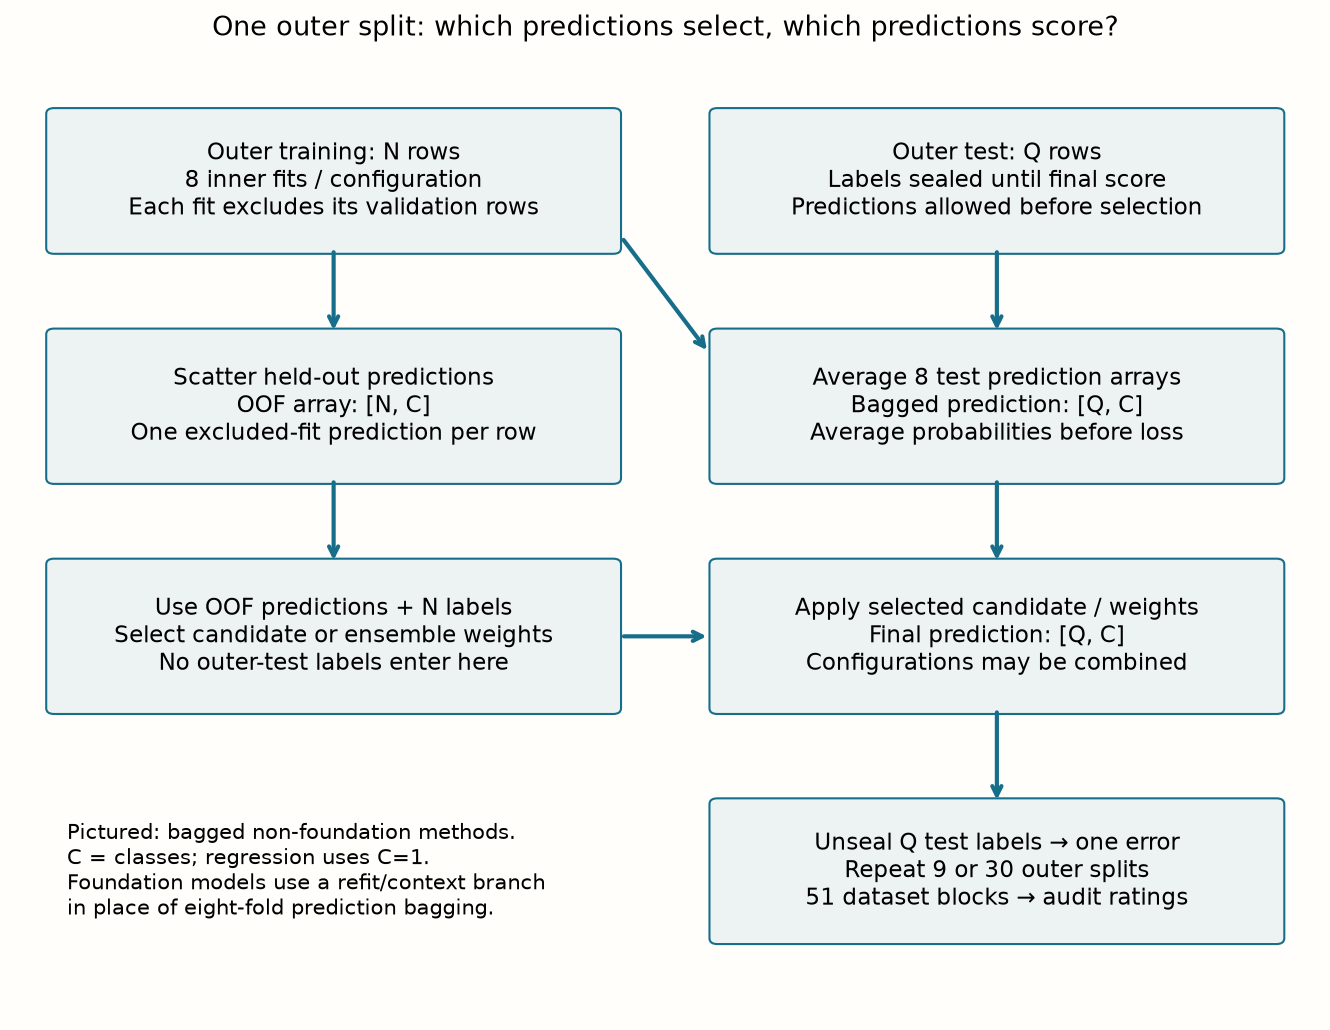

One complete outer-split procedure for bagged non-foundation methods: OOF predictions select; bagged test predictions score after selection. C denotes output classes, or one output for regression. [Open full-size figure](figures/l056/protocol-flow.png).

In [ ]:
# PROVIDED — exact artifact hash checks and loading
def load_snapshot():
    manifest=json.loads((ROOT/'_sources_l056.json').read_text())
    frames=[]
    for item in manifest['artifacts']:
        path=ROOT/'data/l056'/(item['method']+'.parquet')
        assert hashlib.sha256(path.read_bytes()).hexdigest()==item['sha256'],path
        frame=pd.read_parquet(path)
        assert set(frame.ta_suite)=={manifest['artifact_suite']}
        frame['arm']=item['method'].replace('_GPU','')
        frames.append(frame)
    return pd.concat(frames,ignore_index=True)
rows=load_snapshot()
print(rows.shape)
display(rows.groupby(["arm","method_subtype"]).size().unstack())

## TODO 1 · Refuse an invalid comparison
**Goal:** return an error matrix indexed by `(dataset,fold)` with columns in `arms` order. Select the requested arms, require unique nonempty arm names, reject duplicate keys, missing/nonfinite errors, any imputed row and conflicting metrics within a dataset. Require complete coverage across arms. Sort the index.

**Why:** silent deletion of a failed model or unmatched split can change the question. **Hint boundary:** validate the rows before reshaping; absent arm/split cells must raise `ValueError`, not disappear. Do not select by test performance.

In [ ]:
# TODO — aligned_errors
def aligned_errors(rows, arms):
    raise NotImplementedError("Implement this audit operation")

In [ ]:
# CHECK — coverage, failure and metric interventions
base=rows.loc[rows.method_subtype=='default'].copy()
wide=aligned_errors(base,ARMS)
assert wide.shape==(816,4)
assert set(wide.groupby(level='dataset').size())=={9,30}
for bad in (base.iloc[1:],pd.concat([base,base.iloc[:1]]),base.assign(imputed=True)):
    try:aligned_errors(bad,ARMS)
    except ValueError:pass
    else:raise AssertionError('Corrupted evaluation grid accepted')
mixed=base.copy();mixed.loc[mixed.index[0],'metric']='WRONG'
try:aligned_errors(mixed,ARMS)
except ValueError:pass
else:raise AssertionError('Conflicting metrics accepted')
print('PASS: 51 datasets, 816 splits; omissions, duplicates and metric/imputation corruption rejected')

## 4. Follow one error into the aggregate




First align the *evaluation key*: dataset, outer split, method and regime. Every comparison must refer to the same held-out rows and metric. Binary ROC-AUC measures ordering of positive versus negative examples, with larger better; use error `1−AUC`. Multiclass log loss penalizes low probability on the true class, and regression RMSE is the square root of mean squared prediction error; smaller is better for both. The artifact’s `metric_error` already has this orientation. **Do not subtract it from one again.**




RMSE has target units, so averaging its values across unrelated datasets—or mixing it with log loss—is not meaningful. Compare models *within* each dataset/split, where units match. Rank 1 is best. For error vector `[.4, .2, .2, .9]`, the tied second and third entries occupy positions 1 and 2, so the ranks are `[3, 1.5, 1.5, 4]`. Average ties; do not let input order break them.




r(d,s,m) = 1 + count(errors < e) + (count(errors = e) − 1)/2  
R(d,m) = sum_s r(d,s,m) / S(d)  
R(m) = sum_d R(d,m) / D




Here *d* identifies a dataset, *s* its outer split, *m* a method, *e* that method’s error, *S(d)* the dataset’s number of splits, and *D* the number of datasets. First form a split rank, then average inside each dataset, then average the dataset summaries. This gives each dataset equal influence.




**Predict:** if the small dataset is repeated three times with identical ranks, should that alone strengthen its influence? Move the control. The two dataset identities and all their errors stay fixed.





A pairwise win records 1 if A’s error is lower, 0 if higher, and ½ for an exact tie. Average wins over splits inside each dataset, then over datasets. With *M* methods on a complete common grid, a method’s win total against the other methods is `M − rank`; for rank 1.5 among four methods this is 2.5 wins. Our implementation matches this operation in the [pinned upstream evaluator](https://github.com/autogluon/tabarena/blob/e7cc6b049f9be11a6df29eb2560d9ccb2399d95c/packages/bencheval/src/bencheval/elo_utils.py).




**Missingness changes the claim.** Dropping failed evaluations may leave an easier dataset subset. Filling a missing result with a baseline represents a fallback system, not the missing model’s measured performance. Our lab rejects missing keys, duplicate keys, inconsistent metrics and imputed rows. A legitimate subset analysis should name its common task set and exclusion rule before looking at winners.

### Walk from repetitions to one dataset vote

Suppose model A has losses 0.20 and 0.24 on two repetitions of dataset 1, while B has 0.23 and 0.23. Their dataset means are 0.22 and 0.23, so A ranks first on that dataset. Dataset 2 may use a different loss scale; rank there separately after the declared within-dataset aggregation.

The order of operations matters. Ranking every seed and then averaging ranks need not equal averaging losses and ranking the means. For A losses (0.10,0.50,0.50) and B losses (0.40,0.40,0.40), A wins one of three repetitions but has lower mean loss, about 0.367 versus 0.400. The two summaries answer different questions.

Ties receive average positions. If three models have losses (0.2,0.2,0.5), their ranks are (1.5,1.5,3). Assigning ranks (1,2,3) based on column order would invent a distinction absent from the metric. Rounded published scores may also hide genuine differences, which is another reason to prefer saved predictions or unrounded scores for reconstruction.

Relative-error transformations require an explicit denominator. Dividing by a baseline error asks how much loss remains relative to that baseline; subtracting the best and scaling by a range asks a different question. Small or zero denominators can make a normalized score unstable. Inspect the formula and edge-case policy before interpreting a unitless axis.

Ranks discard magnitude. A method that wins by 0.0001 on four tasks and loses by 0.2 on one can have an attractive mean rank but an undesirable deployment profile. Retain task-level effects, failure cases and practical tolerances beside ordinal summaries.

### Reconstruct the appendix's alternative summaries

Appendix A.1 first averages errors across outer folds. On each resulting dataset vector, it reports several summaries with different purposes. Average rank rewards consistent ordinal strength. Harmonic mean rank is D divided by the sum of reciprocal ranks: ranks [1,5] give 2/(1+1/5)=1.667, versus arithmetic mean 3. This emphasizes occasional very strong performance, which may motivate studying ensemble contribution; it does not prove useful prediction diversity.

The normalized score places the best error b at 1 and the median error h at 0: max(0,(h−e)/(h−b)). For errors [.2,.3,.5], h=.3 and b=.2, so scores are [1,0,0]. This discards differences below the median and depends on the competitor pool. If h=b, the formula is undefined; an implementation must specify a policy. Improvability instead uses 100(e−b)/e: at e=.25 and b=.20, 20% of that method's error is removable by switching to the measured best. With zero error its division needs an explicit edge policy too. Neither statistic is an accuracy-point gain.

The new rating exercise computes both orders from the same artifacts: split comparisons averaged by dataset, and comparisons of dataset-mean errors. Everything else is fixed. This is a controlled **analysis** intervention, not new training. Predict which statistics must agree (coverage, raw dataset errors) and which need not (ranks, pairwise frequencies, ratings). Appendix A.1's written mean-error order and our pinned current evaluator's split-aware path are separately labeled; matching one cannot certify the other.

Source: [Appendix A.1, aggregation definitions and Table A.1](https://arxiv.org/html/2506.16791v1#A1.SS1).

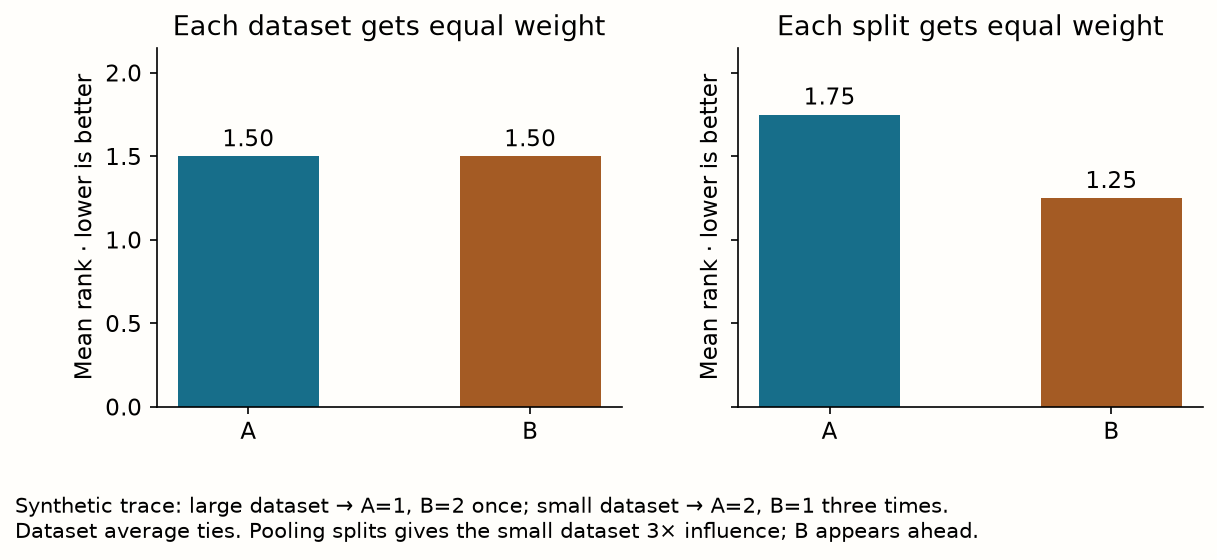

Synthetic fixed-rank example: three repetitions change pooled-split weights; equal dataset averages remain tied. [Open full-size figure](figures/l056/weighting.png).

## TODO 2 · Rank errors, preserving ties
**Goal:** assign lower errors better ranks starting at 1. Ties receive the mean of their occupied ranks. Reject non-vector, empty and nonfinite inputs.

**Why:** input order must not reward one model when errors tie. **Hint boundary:** use comparisons/counts or a stable sorting procedure; do not call a ranking library inside your implementation.

In [ ]:
# TODO — rank_errors
def rank_errors(errors):
    raise NotImplementedError("Implement this audit operation")

In [ ]:
# CHECK — independent reference and invariance to units
from scipy.stats import rankdata
np.testing.assert_array_equal(rank_errors([3,1,1,2]),[4,1.5,1.5,3])
for sample in wide.to_numpy()[::19]:
    np.testing.assert_array_equal(rank_errors(sample),rankdata(sample,method='average'))
    np.testing.assert_array_equal(rank_errors(sample),rank_errors(7*sample+12))
for sample in ([],[1,np.nan],[1,np.inf]):
    try:rank_errors(sample)
    except ValueError:pass
    else:raise AssertionError('Invalid rank input accepted')
print('PASS: ties and monotone unit changes preserve correct ranks')

## TODO 3 · Make each dataset one unit
**Goal:** return one mean-rank row per dataset from a DataFrame indexed by `(dataset,fold)`. Sort datasets; preserve method columns. Reject empty/nonfinite inputs.

**Why:** 30 outer splits should not give a small task 30/9 times another task’s influence. **Hint boundary:** aggregate within dataset first; the caller will average the returned dataset rows.

In [ ]:
# TODO — macro_ranks
def macro_ranks(split_ranks):
    raise NotImplementedError("Implement this audit operation")

In [ ]:
# CHECK — duplicate the whole split pattern of one task
split_ranks=pd.DataFrame([rank_errors(v) for v in wide.to_numpy()],index=wide.index,columns=ARMS)
balanced=macro_ranks(split_ranks)
name=balanced.index[0]
extra=split_ranks.loc[[name]].copy()
extra.index=pd.MultiIndex.from_arrays([extra.index.get_level_values('dataset'),extra.index.get_level_values('fold')+100],names=['dataset','fold'])
doubled=pd.concat([split_ranks,extra])
np.testing.assert_allclose(macro_ranks(doubled),balanced)
assert not np.allclose(doubled.mean(),split_ranks.mean())
display(pd.DataFrame({'equal_datasets':balanced.mean(),'pooled_splits':split_ranks.mean()}))
print('PASS: repeating a dataset pattern changes only the pooled summary')

## 5. Read Elo without calling it accuracy




Elo expresses relative strength through pairwise outcomes. A Bradley–Terry model fits one strength per method so rating differences predict expected wins. The paper uses a scale where a 400-point gap corresponds to 10:1 odds, and anchors the default random forest at 1000. Adding the same constant to all ratings leaves every predicted matchup unchanged. The anchor fixes that arbitrary origin. [Paper §2.3](https://arxiv.org/html/2506.16791v1#S2.SS3).




odds(A beats B) = 10^((E_A − E_B)/400)  
p(A beats B) = odds / (1 + odds)




*E_A* and *E_B* are ratings. At equal ratings, odds=1 and p=½; at a 400-point gap, odds=10 and p=10/11≈.909. This is expected pairwise benchmark success under the rating model, not 90.9% correct labels. It is also not guaranteed to equal every observed pair’s win frequency.




Rank, win rate and Elo discard much of the error margin: winning by .0001 and .1 may count equally. The lab now reconstructs ranks, pairwise wins and fitted Bradley–Terry ratings, and compares observed matchups with the fitted probabilities. The current-source parity check verifies this local evaluator, not the historical Figure 1 pool or original training.

### Elo is a model of relative outcomes

An Elo-style rating maps rating differences to expected pairwise win probabilities under a specified link function. In the common base-10 form, the expected probability that A beats B is 1/[1+10^((R_B−R_A)/400)]. Equal ratings imply 0.5; a 400-point advantage implies about 0.909. The scale constant is a convention, not a unit of prediction accuracy.

The “games” in a benchmark are outcomes derived from task scores. Their definition, tie treatment, weighting and fitting procedure determine what the ratings summarize. A 50-point rating gain cannot be read as a five-percentage-point accuracy gain. It also does not specify the magnitude of loss reduction on a particular dataset.

A rating pool is relational: changing the opponents or included tasks can change fitted ratings. This is appropriate for a relative summary, but it means ratings from differently constructed pools are not automatically interchangeable.

For uncertainty, resample whole dataset blocks jointly across models. Preserve all paired observations belonging to a selected block according to the declared estimator. Resampling individual model scores independently breaks the shared difficulty structure; treating folds as unrelated tasks can overstate task diversity.

### Interpret an interval according to what was resampled

A dataset bootstrap interval describes sensitivity to the observed task collection under the bootstrap model. It does not include uncertainty from unobserved model implementations, alternative tuning budgets or an entirely different deployment population. A seed interval on fixed rows describes an even narrower source of variation.

If two methods are close, report that the local evidence cannot resolve their ordering reliably. A leaderboard must display an order, but a scientific interpretation does not have to pretend that every adjacent position is meaningful. The exit audit should identify which differences are robust, which are practically small and which depend on aggregation choices.

### Fit a rating from observed outcomes

For dataset d and split s, let w(d,s,i,j) be 1 when method i has lower error than j, 0 when higher, and .5 for a tie. Average over splits to obtain W[d,i,j], a [D,M,M] tensor: one complete matchup matrix per dataset. A displayed diagonal of .5 means a self-tie; the fitter excludes self-games. Reciprocity requires W[d,i,j]+W[d,j,i]=1. Sum datasets to obtain C[i,j]. Each pair has D total contests, even though some datasets had more repeated folds.

Use a log-strength t_i for each method and model its win probability as p_ij=1/(1+exp(−(t_i−t_j))). The observed fraction is C[i,j]/D; the fitted probability is a prediction of the rating model. They may differ because one strength per method must explain all pairs simultaneously. A circular pattern of pairwise advantages cannot be matched exactly by a single scalar ordering.

For each unordered pair i<j, the negative log-likelihood is D·log(1+exp(t_i−t_j))−C[i,j]·(t_i−t_j). This is binary cross-entropy written stably with logaddexp. Its derivative with respect to the strength difference is **expected wins minus observed wins**, D·p_ij−C[i,j]. A positive residual says the model predicts too many i wins, so optimization lowers i relative to j. Sum those contributions over opponents. The visible lab solver uses this objective and analytic gradient rather than importing an opaque Elo evaluator.

There are two numerical issues. First, shifting all t values equally changes no probabilities, so we centre ratings at mean 1000 after fitting. The paper instead anchors default RandomForest at 1000; that arm is absent from our pool. Second, if a method wins every contest, an unpenalized maximum can run to infinite strength. The pinned current implementation adds λ·sum(t_i²), with λ=.5/(10⁶·ln(10)²); our fitter uses the same disclosed tiny ridge. That stabilizes separated data but means this is a penalized fit, not an unrestricted maximum-likelihood estimate.

Convert strengths using E_i=1000+400(t_i−mean(t))/ln(10). Check the two-method case before trusting an optimizer: three wins and one loss imply odds 3, a rating gap 400·log10(3)≈190.85, and fitted probability .75, apart from the tiny ridge effect. The fifth live TODO builds W; the provided solver consumes it on all 51 real datasets. A changed TODO therefore changes the reported ratings and bootstrap contrasts.

### What the new execution verifies

The extension compares its fitted four-method ratings with the pinned current upstream `EloHelper.compute_mle_elo_from_ranks` on every regime. It also removes two opponents and refits: the observed CatBoost/TabM frequency stays fixed, but the fitted rating gap can change because other matchups no longer constrain the two strengths. Mean 1000 is re-established in each pool; compare gaps, not absolute levels across pools.

For uncertainty we draw 100 whole-dataset bootstrap samples, refit each sample, and subtract CatBoost's rating in that same draw. This preserves covariance between methods. The interval is a percentile interval for a **rating contrast**, distinct from the older 2,000-draw interval for a **mean rank contrast**. One hundred draws mirror the paper's stated bootstrap count but provide coarse tail resolution; this does not restore its roster, historical weighting, solver or anchor. The source file documents later tolerance changes and the ridge already present in its logistic-regression path. Our new JSON is versioned separately and the historical rank results are retained.

There is a useful same-paper check: Appendix A.1/Table A.1 lists RealMLP (tuned + ensembled) at 1569 and TabM at 1552 on its imputed full roster. Section 3.1 describes the Figure 1 ranking with a different roster. Read the exact figure/table and included methods before saying “the paper winner”; do not assume one ranking applies to every panel. A roster difference is a possible source of a changed ordering, not by itself a numerical reconstruction of why it changed.

The official reconstruction command targets a camera-ready collection at a later repository revision. The initial paper, that collection, the public current leaderboard and this four-method audit are four different evidence identities. To claim exact recovery, reconcile their versions, opponent/regime pool, aggregation order, missing-result fallback, anchor and bootstrap before comparing a number. Running a current solver successfully settles only the current-solver question.

Source: [paper §2.3](https://arxiv.org/html/2506.16791v1#S2.SS3) and [pinned evaluator, `_rank_win_matrix` and `_bradley_terry_from_win_totals`](https://github.com/autogluon/tabarena/blob/e7cc6b049f9be11a6df29eb2560d9ccb2399d95c/packages/bencheval/src/bencheval/elo_utils.py).

In [ ]:
# PROVIDED — trace the Elo mapping, not an Elo fitting routine
gap=400
odds=10**(gap/400);probability=odds/(1+odds)
assert np.isclose(probability,10/11)
print('Expected benchmark win probability:',probability,'; not classification accuracy')

## TODO 4 · Resample paired datasets
**Goal:** return `[mean_gap, lower_95, upper_95]` using the empirical 2.5/97.5 percentiles of `n_boot` bootstrap means. Use `np.random.default_rng(seed)` and resample D gaps with replacement per draw. Require a finite vector of at least two datasets and at least 100 draws.

**Why:** paired comparisons must travel together; outer folds overlap. **Hint boundary:** each input entry is already one dataset’s method difference. Bootstrap these entries, not individual split errors.

In [ ]:
# TODO — bootstrap_gap
def bootstrap_gap(dataset_gaps, seed=56, n_boot=2000):
    raise NotImplementedError("Implement this audit operation")

In [ ]:
# CHECK — known constant and bounded reproducible resampling
np.testing.assert_allclose(bootstrap_gap(np.full(6,-.4)),[-.4,-.4,-.4])
g=np.array([-1.,0.,2.,1.])
actual=bootstrap_gap(g,seed=56)
np.testing.assert_array_equal(actual,bootstrap_gap(g,seed=56))
assert actual[0]==.5 and g.min()<=actual[1]<=actual[2]<=g.max()
print('PASS: paired dataset bootstrap is reproducible and bounded')

## PROVIDED · Complete evaluator
Read the remaining implementation. It calls **your four functions above** for every regime. Win rates are computed pairwise within the same split and then dataset-balanced. The supplementary Friedman/Nemenyi summary ranks mean errors per dataset, a different order of operations. The helper is inlined below; no packaged evaluator replaces your functions.

In [ ]:
# PROVIDED — complete live audit
def summarize(rows, arms, n_boot=2000):
    """Calls the four live learner operations; all regimes use the same arms."""
    result = {}
    for regime in ('default','tuned','tuned_ensemble'):
        frame = rows.loc[rows.method_subtype == regime]
        errors = aligned_errors(frame,arms)
        ranks = pd.DataFrame([rank_errors(row) for row in errors.to_numpy()],index=errors.index,columns=arms)
        per_dataset = macro_ranks(ranks)
        # Pairwise win probability: ties count as half; lower error wins.
        wins = {}
        for a in arms:
            for b in arms:
                if a == b: continue
                v = ((errors[a] < errors[b]).astype(float)+.5*(errors[a]==errors[b]))
                wins[a+' / '+b] = float(v.groupby(level='dataset').mean().mean())
        gap = per_dataset['TabM']-per_dataset['CatBoost']
        # Supplementary Friedman/Nemenyi: rank MEAN error within each dataset.
        # It answers a different question from averaging split-level ranks.
        from scipy.stats import friedmanchisquare, studentized_range, rankdata
        means = errors.groupby(level='dataset').mean()
        friedman = friedmanchisquare(*means.to_numpy().T)
        sd = errors.groupby(level='dataset').std().reset_index().astype(object)
        sd = sd.where(pd.notna(sd),None)
        cd = float(studentized_range.ppf(.95,len(arms),np.inf)/np.sqrt(2)*np.sqrt(len(arms)*(len(arms)+1)/(6*len(means))))
        result[regime] = dict(datasets=len(per_dataset),outer_splits=len(errors),
            mean_ranks=per_dataset.mean().to_dict(),naive_split_ranks=ranks.mean().to_dict(),
            dataset_ranks=per_dataset.reset_index().to_dict(orient='records'),
            dataset_errors=means.reset_index().to_dict(orient='records'),
            split_sd=sd.to_dict(orient='records'),
            win_rates=wins,tabm_minus_catboost_rank_gap=bootstrap_gap(gap,n_boot=n_boot).tolist(),
            friedman_p=float(friedman.pvalue),nemenyi_cd=cd,
            mean_error_ranks=dict(zip(arms,rankdata(means.to_numpy(),axis=1).mean(axis=0))))
    return result

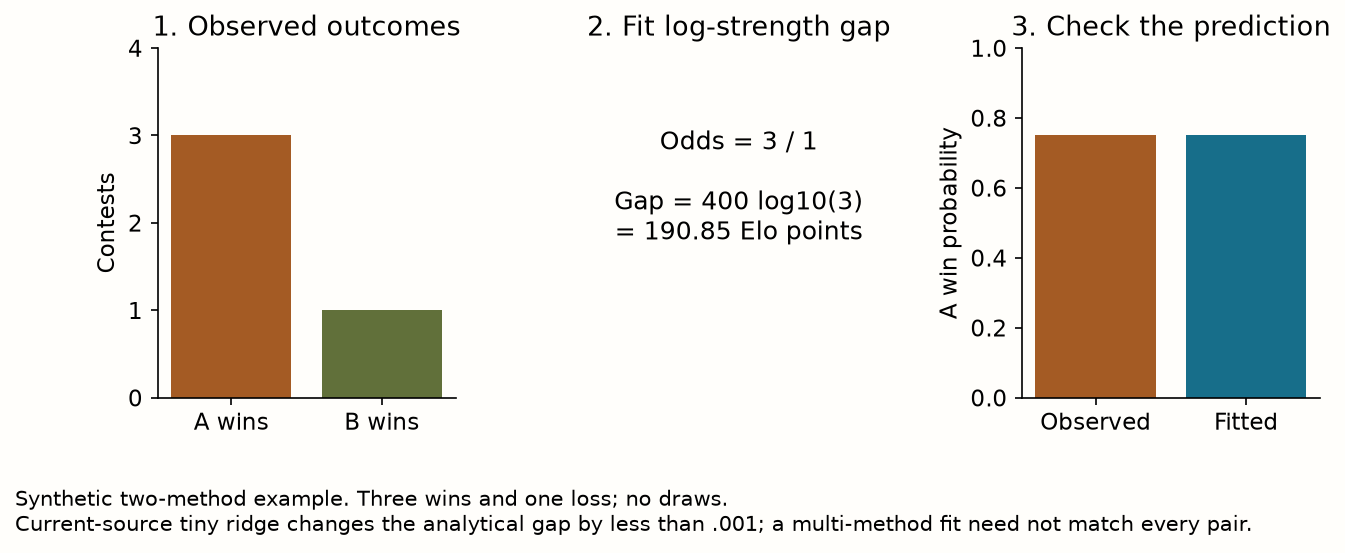

Synthetic analytical trace: three A wins and one B win give odds 3, rating gap 190.85 and fitted win probability .75. The ridge makes a negligible correction. [Open full-size figure](figures/l056/rating-trace.png).

## TODO 5 · Make the contests that the rating solver fits
**Goal:** from the complete lower-is-better error matrix, build a NumPy tensor `[datasets,methods,opponents]`. For each split compare every method with every opponent; a win is 1, tie .5, loss 0. Average splits within each dataset, retaining sorted dataset order and the input method order. Reject empty/nonfinite inputs.

**Why:** the rating solver cannot repair reversed winners or dataset weights. **Hint boundary:** compare a column-expanded error array with a row-expanded one; group by dataset before averaging. The diagonal should display .5, but the fitter excludes self-games. Predict the tensor for one A win and three repetitions of a B win on a different dataset.

In [ ]:
# TODO — paired_wins
def paired_wins(errors):
    raise NotImplementedError("Implement this audit operation")

In [ ]:
# CHECK — orientation, pairing, ties and equal dataset influence
ix=pd.MultiIndex.from_tuples([('a',0),('b',0),('b',1),('b',2)],names=['dataset','fold'])
toy=pd.DataFrame([[0,1],[1,0],[1,0],[1,0]],index=ix,columns=['A','B'])
w=paired_wins(toy)
assert w.shape==(2,2,2)
np.testing.assert_allclose(w.mean(0),.5)
np.testing.assert_allclose(w+w.transpose(0,2,1),1)
assert w[0,0,1]==1 and w[1,0,1]==0
print('PASS: one vote per dataset; row method is the winning candidate')

## PROVIDED · Fit the Bradley–Terry objective
Read the pairwise negative log-likelihood and its gradient. `observed` counts dataset-balanced wins, while `d * expit(delta)` predicts them. Subtracting the two drives optimization. `logaddexp` avoids overflow; the disclosed ridge stabilizes undefeated methods. Mean-centering at 1000 sets a local coordinate origin. It does not calibrate against the absent RandomForest arm.

This is a transparent reimplementation of the pinned **current** objective. The original Figure 1 method pool, solver history and random-forest anchor are not recovered.

In [ ]:
# PROVIDED — visible fitting and dataset-refit bootstrap
def fit_elo(dataset_wins):
    """Fit complete balanced contests; centre ratings at 1000, not paper RF anchor.

    Matches e7cc6b0 EloHelper ridge and likelihood, using an explicit pair matrix.
    Input diagonal is .5 for display but contributes no self-contests to the fit.
    """
    from scipy.optimize import minimize
    from scipy.special import expit
    w=np.asarray(dataset_wins,dtype=float)
    if (w.ndim!=3 or w.shape[0]<1 or w.shape[1]<2 or w.shape[1]!=w.shape[2]
        or not np.isfinite(w).all() or np.any((w<0)|(w>1))
        or not np.allclose(w+w.transpose(0,2,1),1)):
        raise ValueError('Expected D x M x M reciprocal win probabilities')
    d,m,_=w.shape
    i,j=np.triu_indices(m,1)
    observed=w.sum(axis=0)[i,j]
    ridge=.5/(1e6*np.log(10)**2)
    def objective(t):
        delta=t[i]-t[j]
        loss=np.sum(d*np.logaddexp(0,delta)-observed*delta)+ridge*(t@t)
        residual=d*expit(delta)-observed
        gradient=2*ridge*t
        np.add.at(gradient,i,residual);np.add.at(gradient,j,-residual)
        return loss,gradient
    result=minimize(objective,np.zeros(m),jac=True,method='L-BFGS-B',
                    options={'maxiter':10000,'ftol':1e-15,'gtol':1e-12})
    if not result.success and np.max(np.abs(result.jac))>1e-6:
        raise RuntimeError('Rating optimizer failed: '+result.message)
    return 1000+400*(result.x-result.x.mean())/np.log(10)

def rating_audit(errors, n_boot=100, seed=56):
    """All outputs depend on the live paired_wins and fit_elo implementations."""
    from scipy.special import expit
    w=paired_wins(errors)
    ratings=fit_elo(w)
    # A dataset mean error supplies one contest per dataset (Appendix A.1 order).
    means=errors.groupby(level='dataset',sort=True).mean()
    mean_ratings=fit_elo(paired_wins(means))
    rng=np.random.default_rng(seed)
    # Anchor contrasts to CatBoost in every draw, keeping paired methods together.
    anchor=list(errors.columns).index('CatBoost')
    boot=np.array([fit_elo(w[rng.integers(len(w),size=len(w))]) for _ in range(n_boot)])
    contrasts=boot-boot[:,anchor,None]
    predicted=expit((ratings[:,None]-ratings[None,:])*np.log(10)/400)
    return dict(methods=list(errors.columns),datasets=len(w),ratings=ratings.tolist(),
        mean_error_ratings=mean_ratings.tolist(),observed_wins=w.mean(0).tolist(),
        fitted_wins=predicted.tolist(),max_matchup_residual=float(np.abs(predicted-w.mean(0)).max()),
        catboost_contrast=(ratings-ratings[anchor]).tolist(),
        catboost_contrast_interval=np.quantile(contrasts,[.025,.975],axis=0).T.tolist(),
        bootstrap_draws=n_boot,bootstrap_seed=seed,
        convention='Each regime separately; field mean 1000; current ridge; no RF anchor',
        paper_table='INCOMPARABLE')

In [ ]:
# CHECK — analytical two-method answer and complete separation
analytic=np.array([[[.5,.75],[.25,.5]]]*4)
r=fit_elo(analytic)
assert abs((r[0]-r[1])-400*np.log10(3))<.001
np.testing.assert_allclose(fit_elo(analytic[:,::-1,::-1]),r[::-1],atol=1e-5)
assert np.isfinite(fit_elo(np.array([[[.5,1],[0,.5]]]))).all()
print('PASS: 3:1 odds gives a 190.85-point gap; ridge keeps an undefeated arm finite')

## First run · one split per dataset
This is a Lite sensitivity view, not the full evidence. Predict whether a single split must preserve the all-split ordering. No rankings are forced to change. More repeated evaluations can stabilize estimates without adding new independent datasets.

In [ ]:
# PROVIDED — Lite view uses the live functions
lite=summarize(rows.loc[rows.fold==0],ARMS)
display(pd.DataFrame({k:v['mean_ranks'] for k,v in lite.items()}))
assert all(v['datasets']==51 and v['outer_splits']==51 for v in lite.values())

## Required next step · all archived outer splits
No gating or cloud run is necessary: the full score artifact is small. Run the exact same functions on all 816 outer splits. This expands the analysis, not model training. The subsequent CHECK compares the numerical reconstruction, not a claim of fresh paper replication.

In [ ]:
# PROVIDED — full published-result reanalysis
full=summarize(rows,ARMS)
display(pd.DataFrame({k:v['mean_ranks'] for k,v in full.items()}))
OUT=ROOT/'data/cache/l056';OUT.mkdir(parents=True,exist_ok=True)
(OUT/'student-audit.json').write_text(json.dumps(full,indent=2))
print('Saved',OUT/'student-audit.json')

In [ ]:
# CHECK — audited reference, not a substituted experiment
reference=json.loads((ROOT/'_verify_l056_results.json').read_text())
for regime,s in full.items():
    assert s['datasets']==51 and s['outer_splits']==816
    for arm in ARMS:assert abs(s['mean_ranks'][arm]-reference['summary'][regime]['mean_ranks'][arm])<1e-12
    np.testing.assert_allclose(s['tabm_minus_catboost_rank_gap'],reference['summary'][regime]['tabm_minus_catboost_rank_gap'],atol=1e-12)
print('PASS: live implementation reproduces the recorded aggregate audit')

## Required rating experiment · fit, perturb and diagnose
**Predict first:** with the same four methods, must the fitted probability exactly match every observed matchup? Must ranking mean errors preserve split-based ratings? Must the CatBoost/TabM gap stay fixed after removing the other opponents?

Run all three regimes with your live `paired_wins`, then fit 100 paired dataset resamples for each. Hold the artifact bytes and solver fixed. This takes seconds to a minute on CPU. The old mean-rank interval used 2,000 resamples; the new interval is in **Elo contrast units**, so do not place them on one axis.

In [ ]:
# PROVIDED — ratings, matched reference and two-opponent intervention
rating_results={}
for regime in ('default','tuned','tuned_ensemble'):
    e=aligned_errors(rows.loc[rows.method_subtype==regime],ARMS)
    rating_results[regime]=rating_audit(e)
    reduced=fit_elo(paired_wins(e[['CatBoost','TabM']]))
    rating_results[regime]['two_method_gap']=float(reduced[1]-reduced[0])
rating_reference=json.loads((ROOT/'_verify_l056_elo_results.json').read_text())
for regime,r in rating_results.items():
    np.testing.assert_allclose(r['ratings'],rating_reference['results'][regime]['ratings'],atol=1e-7)
    np.testing.assert_allclose(r['catboost_contrast_interval'],rating_reference['results'][regime]['catboost_contrast_interval'],atol=1e-7)
display(pd.DataFrame({k:dict(zip(ARMS,v['ratings'])) for k,v in rating_results.items()}))
r=rating_results['tuned_ensemble']
display(pd.DataFrame(np.asarray(r['fitted_wins'])-np.asarray(r['observed_wins']),index=ARMS,columns=ARMS))
print('Maximum fitted-minus-observed matchup difference:',r['max_matchup_residual'])
print('TabM-CatBoost gaps: four methods',r['catboost_contrast'][3],'two methods',r['two_method_gap'])
display(pd.DataFrame({'split_contests':r['ratings'],'mean_error_contests':r['mean_error_ratings']},index=ARMS))
(OUT/'student-rating-audit.json').write_text(json.dumps(rating_results,indent=2))
print('PASS: fresh live rating analysis matches current reference; initial paper table remains INCOMPARABLE')

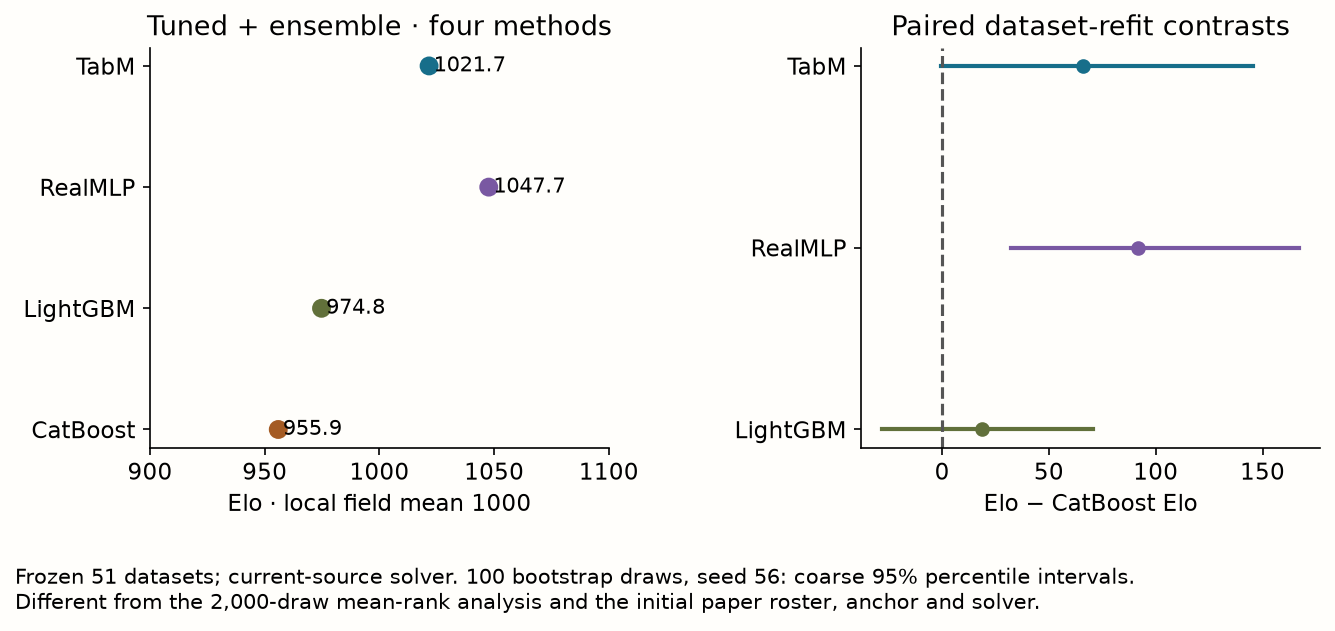

New author measurement: four-method ratings and paired CatBoost contrasts. The source is the current solver and frozen score files; these are not the paper table. [Open full-size figure](figures/l056/rating-evidence.png).

### Interpretation CHECK · recover what ranks discard
The next cell shows one real task's errors in its own metric, where subtraction has a meaningful unit. Inspect the task rather than choosing a pleasing test result. Then identify one regime change where a method's rank worsens: this does not establish that its own error worsened, because its competitors changed too. Explain the difference between an absolute loss intervention and a relative ranking intervention.

## 6. Recompute, then interpret





**Uncertainty unit:** define one paired gap per dataset, `g(d)=R(d,TabM)−R(d,CatBoost)`. Resample 51 whole datasets with replacement, preserving each dataset’s paired methods and all its splits; average the sampled gaps. Repeat 2,000 times with seed 56. The 2.5th and 97.5th percentiles form the displayed interval. This *cluster bootstrap* treats datasets as sampling units rather than treating dependent outer folds as independent observations.





The ensembled point gap is −.373, but its interval [−.797, +.037] crosses zero. That does not establish equivalence. The curated datasets are not a random sample of all business problems; the bootstrap’s population interpretation is approximate. It also cannot account for unmeasured training failures, a different method pool, or deployment shift. The three regime contrasts are exploratory, not a set of confirmatory discoveries.





[Evidence JSON](_verify_l056_results.json) includes per-dataset means, outer-split sample standard deviations, all aggregate summaries, the one-split sensitivity analysis, package versions and source hashes. Outer-split SD describes variability under the published split procedure; overlapping training sets prevent interpreting SD/√splits as an IID standard error. Exact local primitive parity error is below 2×10⁻¹⁵. [Read the reproduction contract](l056-reproduction.md).



[New fitted-rating evidence JSON](_verify_l056_elo_results.json): current-source parity, each regime’s ratings and observed/fitted matchup probabilities, 100-refit bootstrap contrasts, and two-method pool comparison. The ensembled TabM–CatBoost gap is +65.74 Elo, versus +68.07 in the two-method pool; its coarse interval is [−0.57,+145.59]. These are rating units, not the historical mean-rank interval.

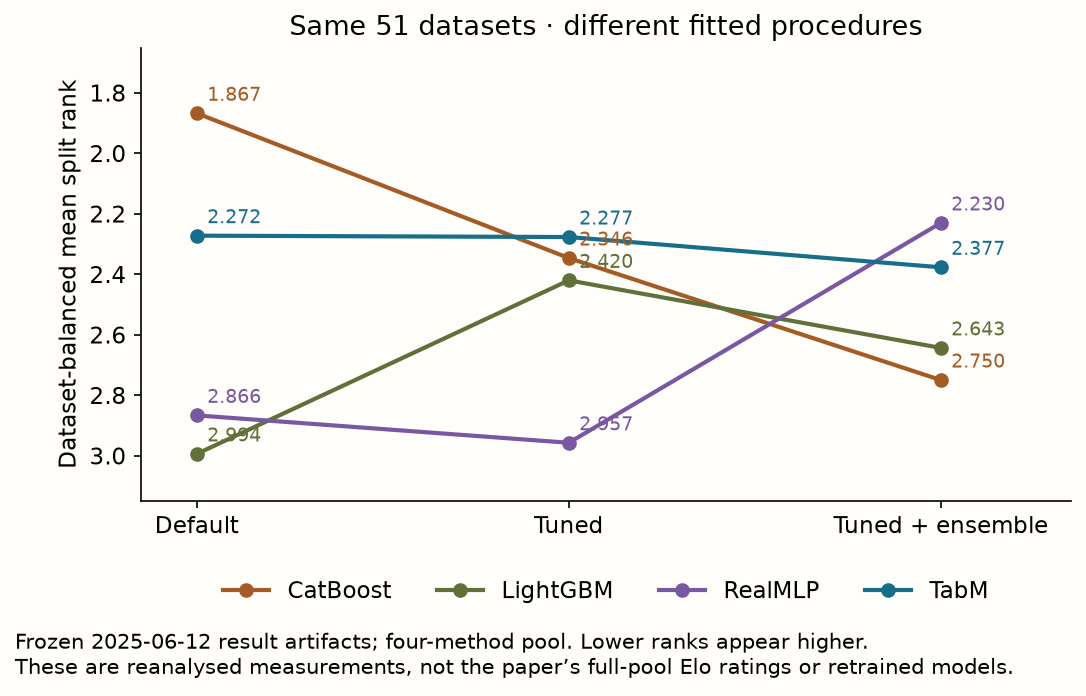

Author-reference four-method ranks; same 51 datasets. Different from full-pool paper Elo. [Open full-size figure](figures/l056/ranks.png).

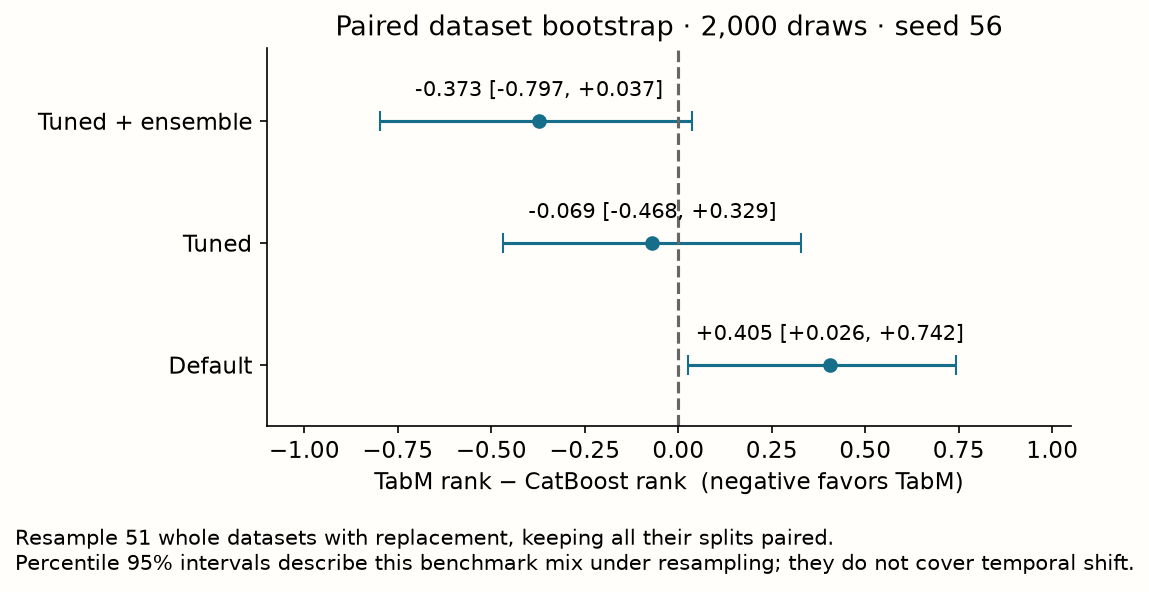

Author-reference paired dataset bootstrap. Negative favors TabM; crossing zero does not establish equivalence. [Open full-size figure](figures/l056/uncertainty.png).

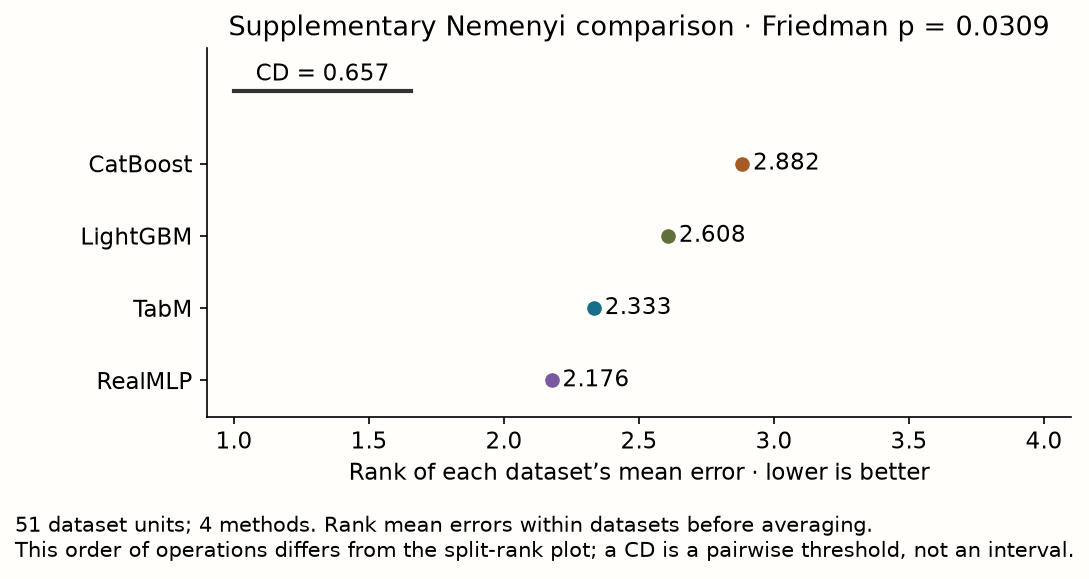

Supplementary rank-of-mean-error analysis, separate from average split ranks; exploratory tests. [Open full-size figure](figures/l056/critical-difference.png).

In [ ]:
# PROVIDED — one real dataset, uncertainty and all-split sensitivity
dataset=sorted(rows.dataset.unique())[0]
sample=rows.loc[(rows.dataset==dataset)&(rows.method_subtype=='tuned_ensemble')]
task_table=sample.groupby('arm').metric_error.agg(['mean','std','count']).reindex(ARMS)
print(dataset,'metric:',sample.metric.unique())
display(task_table)
print('SD is across published outer splits; it is not an independent-fold standard error.')
comparison=pd.DataFrame({'one_split':lite['tuned_ensemble']['mean_ranks'],'all_splits':full['tuned_ensemble']['mean_ranks']})
display(comparison)
print('TabM−CatBoost paired rank gap and interval:',full['tuned_ensemble']['tabm_minus_catboost_rank_gap'])

## EXIT TICKET · an audit you would sign
Include snapshot/hash identity, method pool, regimes, metric orientation and coverage; the three-regime table; one dataset’s mean/SD; naive-versus-balanced ranks; the paired ensemble interval; and one-split versus all-split sensitivity. Add fitted-versus-observed matchup residuals, split-first versus mean-error-first ratings, the two-method pool intervention and the 100-draw rating contrast interval.

Write your own explanation: why does the full-pool paper ranking not have to equal these four-method mean ranks? What supports a stronger tabular baseline, and what temporal relational claim is still unanswered? Distinguish **released-score reanalysis / source primitive parity / exact table reproduction / fresh training**. State which are verified and which are not.

Paste the output and your explanation to the tutor. Running teacher solutions is not independent mastery evidence.

In [ ]:
# EXIT — replace the placeholder with your own interpretation
interpretation="WRITE your defensible conclusion here"
exit_ticket={'snapshot':'tabarena-2025-06-12','source_manifest':json.loads((ROOT/'_sources_l056.json').read_text()),
    'rank_table':{k:v['mean_ranks'] for k,v in full.items()},'dataset':dataset,'dataset_errors':task_table.to_dict(),
    'naive_vs_balanced':{'balanced':balanced.mean().to_dict(),'naive':split_ranks.mean().to_dict()},
    'ensemble_gap':full['tuned_ensemble']['tabm_minus_catboost_rank_gap'],
    'lite_vs_full':comparison.to_dict(),'ratings':rating_results,'interpretation':interpretation,
    'reanalysis':'PASS','training':'NOT_RUN','paper_table':'INCOMPARABLE'}
(OUT/'exit.json').write_text(json.dumps(exit_ticket,indent=2))
print('Saved',OUT/'exit.json')
print('EXIT needs your written interpretation before submission.')

## Separate unrun track · full official leaderboard
For full-pool ratings, use the pinned official example and environment instructions in [the reproduction contract](l056-reproduction.md#next-reproduction-track-full-official-leaderboard). It is **NOT_RUN** here. Reconcile the exact paper version, roster, imputation, evaluator and bootstrap before claiming historical table recovery. Fresh training is a different, still unrun task; score-only files cannot verify it.

Ask the tutor about any failing CHECK or source discrepancy. The next integer-numbered unit, L057, builds cross-family ensembles.